# Matrice di confusione

Le metriche derivate dalla matrice di confusione sono fondamentali per capire come è distribuito l'errore di un modello predittivo.

- **Accuracy**: Si osserva che questa metrica non è adatta per valutare dataset sbilanciati(ma è valida per bilanciati), in quanto non tiene conto della reale distribuzione delle classi. *Un modello potrebbe ottenere un'alta accuracy semplicemente predicendo sempre la classe maggioritaria, ignorando completamente quella minoritaria.*

- **F1-Score**: Per ovviare a questo problema si utilizza l'F1-Score. Essendo la media armonica tra Precision e Recall, penalizza fortemente i valori estremi o molto sbilanciati, rivelandosi *una metrica eccellente per casi di imbalanced learning.*

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import random as rn

k, eps = 15, .9
y_test = [0,1]*k
test_pred = [y if rn.random() <= eps else (y+1)%2 for y in y_test]


cm = confusion_matrix(y_test, test_pred)

print("Matrice di confusione:")
print(cm)

Matrice di confusione:
[[12  3]
 [ 2 13]]


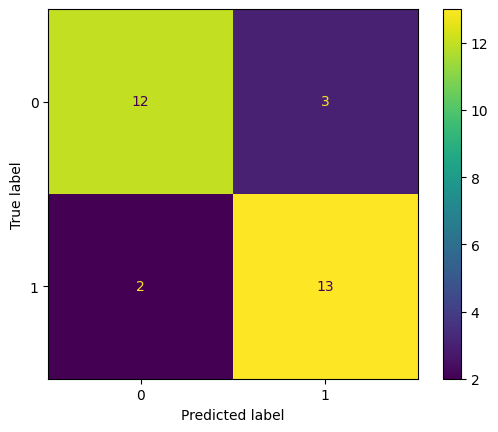

In [38]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [3]:
tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()

print(tn, fp, fn, tp)

14 1 0 15


## Precision e recall

In [4]:
precision = tp / (tp + fp) # frazione di positivi trovati  tra tutti i predetti positivi
recall = tp / (tp + fn) # frazione di positivi trovati tra tutti i positivi reali

print("\nPrecision:", precision)
print("Recall:", recall)


Precision: 0.9375
Recall: 1.0


- alta precision + bassa recall → il modello è “prudente” ma perde molti positivi
- bassa precision + alta recall → il modello trova molti positivi ma con molti errori
- F1 alto → buon equilibrio tra le due

## F1 score

$$
F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$


- assume valore massimo pari a 1 quando precision e recall sono entrambe perfette,
- è basso quando uno dei due valori è basso,
- penalizza fortemente gli squilibri tra precision e recall (più della media aritmetica).

Utile quando:
- le classi sono sbilanciate,
- i falsi positivi e i falsi negativi hanno importanza simile

In [10]:
F1 = 2*(precision*recall)/(precision+recall)
print(F1)

0.967741935483871


## ROC Curve (Receiver Operating Characteristic)

La **ROC curve (Receiver Operating Characteristic)** è una rappresentazione grafica che descrive le prestazioni di un classificatore binario al variare della soglia decisionale.

Le metriche che evidenzia sono le segueti

- **True Positive Rate (TPR)**: percentuale dei positivi classificati come positivi
$$
TPR = \frac{TP}{TP+FN}
$$

- **False Positive Rate (FPR)**: percentuale dei negativi classificati come positivi
$$
FPR = \frac{FP}{FP+TN}
$$

Tipicamente i modelli di classificazione calcolano un valore compreso tra 0 e 1 interpretato come la probabilità che il campione sia positivo. La classe è stabilita applicando una soglia, tipicamente 0.5, a questo valore.

Ad ogni soglia corrisponde una coppia $(FPR, TPR)$. La ROC curve è il luogo dei punti $(FPR, TPR)$ ottenuti variando la soglia del classificatore.

Quindi se nella ROC compare un punto in posizione $(x,y)$ allora esiste una soglia $t$ tale che il classificatore ha:
- FPR = $x$
- TPR = $y$

# spiegazione dettagliata ROC curve e AUC metric
Per comprendere la ROC curve, bisogna ricordare che molti classificatori (non solo quelli lineari, ma in generale quelli che restituiscono uno score o una probabilità) calcolano per un campione $x$ un valore continuo compreso tra $[0, 1]$.


Applicando una certa soglia di decisione (threshold), questo valore continuo viene convertito in una classe discreta ($0$ o $1$). Al variare di questa soglia, per un dato classificatore vengono definiti:
- **TPR (True Positive Rate o Recall)**: La percentuale di positivi reali che sono stati classificati correttamente come positivi. Calcolato come $\frac{TP}{TP + FN}$.
- **FPR (False Positive Rate)**: La percentuale di negativi reali che sono stati erroneamente classificati come positivi. Calcolato come $\frac{FP}{FP + TN}$.


Per ogni possibile valore di soglia, otteniamo una coppia di coordinate $(FPR, TPR)$. Riportando queste coppie su un piano cartesiano, esse generano una curva continua nota come ROC curve.


**Riassumendo**: se ti posizioni in un qualsiasi punto della curva, quel punto indica che per il modello $M$ esiste uno specifico valore di threshold $T$ per cui il modello ottiene esattamente quel TPR e quel FPR.


AUC
------------------------------------------------
- **Il Classificatore Perfetto**: Lo si ottiene se esiste un valore di threshold tale per cui nella curva compare il punto $(TPR=1, FPR=0)$. Geometricamente, questo significa che più la curva ROC si spinge e si "gonfia" verso l'angolo in alto a sinistra del piano, migliore è il classificatore.Il Classificatore 

- **Casuale (Random)**: Se la curva coincide esattamente con la bisettrice del piano (la linea diagonale), il classificatore non ha alcun potere predittivo ed equivale a tirare una moneta.

- **AUC (Area Under the Curve)**: Questo concetto sintetizza l'intera ROC curve in un singolo numero. L'AUC è letteralmente l'area geometrica sottostante alla curva ROC. Tanto più l'area si avvicina a $1$, tanto più il classificatore è eccellente. Un valore di $0.5$ corrisponde all'area sottostante la bisettrice (classificatore random).

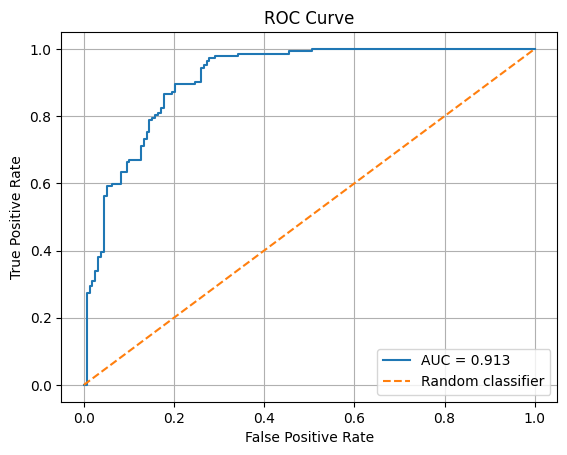

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Dataset sintetico
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    random_state=42
)

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Modello (probabilistico)
model = LogisticRegression()
model.fit(X_train, y_train)

# 4. Probabilità della classe positiva, ottieni il dato grezzo senza treshold
# OSSIA: fai il predict sennza applicare la funzione a soglia
y_scores = model.predict_proba(X_test)[:, 1]

# 5. ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc = roc_auc_score(y_test, y_scores)

# 6. Plot
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

**interpretazione**: Per un classificatore perfetto esiste una soglia per cui ha pochi falsi positivi (FPR vicino a 0) e tanti veri positivi (TRP vicino a 1). Quindi più una curva occupa l'ancolo in alto a sinistra, più il classificatore è valido.

Se la curva è la diagonale, allora per ogni soglia, se questa garantisce un basso grado di falsi positivi allora è basso anche il grado di veri positivi.

Maggiore è l'area sotto la curva (**AUC**), migliore è il classificatore per quel determinato problema.

# Classificazione di Dataset Sbilanciati con SVM

Si vuole affrontare il problema della classificazione di dataset sbilanciati, costituiti da due classi:

- classe `0` (maggioritaria),
- classe `1` (minoritaria).

Si consideri un dataset sintetico con forte sbilanciamento (ad esempio 95% dei campioni appartenenti alla classe `0` e 5% alla classe `1`).



---

## 1. Bilanciamento dei dati per training e validazione

1. Generare un dataset sintetico di classificazione binaria.

2. Suddividere il dataset in:
   - training set,
   - test set.

3. **A partire dal training set, estrarre inizialmente un sottoinsieme bilanciato**, selezionando casualmente lo stesso numero di campioni per ciascuna classe, pari al numero di campioni della classe minoritaria.

4. Applicare una validazione incrociata stratificata a `K` fold sul training set bilanciato ottenuto al punto precedente.

5. Al termine della cross-validation, addestrare il modello finale su un training set bilanciato (ottenuto come al punto 3) e valutarlo su un test set non bilanciato, mantenendo la distribuzione originale delle classi, al fine di ottenere una stima realistica delle prestazioni del modello in condizioni di sbilanciamento.

6. Valutare il modello con una metrica appropriata. 


In [4]:
X, Y= make_classification(n_samples= 1000, n_features= 7, n_informative= 3, n_redundant=2 , n_classes= 2, weights=[0.95, 0.5])

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

m0 = (y_train==0)
X0 = X_train[m0]
y0=y_train[m0]

m1 = (y_train==1)
X1 = X_train[m1]
y1=y_train[m1]

num_minoritaria = X1.shape[0]

indici0 = np.random.choice(X0.shape[0], size= num_minoritaria, replace= False)
indici1 = np.random.choice(X1.shape[0], size= num_minoritaria , replace= False)

X0_bil=X0[indici0]
y0_bil=y0[indici0]

X1_bil=X1[indici1]
y1_bil=y1[indici1]

X_train_bilanciato = np.vstack((X0_bil, X1_bil))
y_train_bilanciato = np.concatenate((y0_bil, y1_bil))

#classi, conteggi = np.unique(y_train_bilanciato, return_counts=True)---check per vedere se bilanciato----#

In [5]:
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC

C_values = [0.1, 1, 10,12 ]
gamma_values=[0.1, 0.002, 0.03]

best_score = 0
best_params = None

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

for C in C_values:
    for gamma in gamma_values:

        fold_scores = []

        # ======================================================
        # Cross-validation
        # ======================================================
        for train_idx, val_idx in kf.split(X_train_bilanciato, y_train_bilanciato):

            X_train, X_val = X_train_bilanciato[train_idx], X_train_bilanciato[val_idx]
            y_train, y_val = y_train_bilanciato[train_idx], y_train_bilanciato[val_idx]

            model = SVC(kernel="linear", C=C, gamma=gamma)

            model.fit(X_train, y_train)
            preds = model.predict(X_val)

            acc = np.mean(y_val==preds)
            fold_scores.append(acc)

        mean_score = np.mean(fold_scores)

        print(f"C={C:<3} gamma={gamma:<5} -> CV accuracy = {mean_score:.4f}")

        if mean_score > best_score:
            best_score = mean_score
            best_params = (C, gamma)
print("finitoooooooooooooooooooooooooooooooooooo")

print("trovato ", best_score, " e ", best_params)

C=0.1 gamma=0.1   -> CV accuracy = 0.9177
C=0.1 gamma=0.002 -> CV accuracy = 0.9177
C=0.1 gamma=0.03  -> CV accuracy = 0.9177
C=1   gamma=0.1   -> CV accuracy = 0.9148
C=1   gamma=0.002 -> CV accuracy = 0.9148
C=1   gamma=0.03  -> CV accuracy = 0.9148
C=10  gamma=0.1   -> CV accuracy = 0.9177
C=10  gamma=0.002 -> CV accuracy = 0.9177
C=10  gamma=0.03  -> CV accuracy = 0.9177
C=12  gamma=0.1   -> CV accuracy = 0.9177
C=12  gamma=0.002 -> CV accuracy = 0.9177
C=12  gamma=0.03  -> CV accuracy = 0.9177
finitoooooooooooooooooooooooooooooooooooo
trovato  0.9177062374245473  e  (10, 0.1)


In [7]:
model = SVC(kernel="rbf", C=best_params[0], gamma=best_params[1])

model.fit(X_train, y_train)

y_pred_rbf = model.predict(X_test)
print("Accuracy SVM RBF:", np.mean(y_test == y_pred_rbf))

Accuracy SVM RBF: 0.9733333333333334


In [ ]:
tn, fp, fn, tp = confusion_matrix(y_test,y_pred_rbf ).ravel()

precision = tp/(tp + fp )
recall = tp / (tp + fn)
F1 = 2*(precision*recall)/(precision+recall)
print("F1:", F1)
print("\nPrecision:", precision)
print("Recall:", recall)


----

## 2. Modifica dell'implementazione della SVM


Si consideri la formulazione soft-margin della SVM:

$$
\frac{1}{2}\|w\|^2
+
C\sum_{i=1}^{N}\xi_i
$$

Modificare l'implementazione sostituendo il parametro globale `C` con un parametro specifico per ciascun campione:

$$
C_i = C \cdot v_{i}
$$

dove:

- $v_{i}$ è il peso associato alla classe del campione $i$,

I pesi di classe sono definiti come inversamente proporzionali alla frequenza delle classi nel training set:

$$
v_c = \frac{n}{2n_c}
$$

dove:

- $n$ è il numero totale di campioni del training set,
- $n_c$ è il numero di campioni appartenenti alla classe $c$.

In questo modo:

- la classe maggioritaria riceve un peso minore;
- la classe minoritaria riceve un peso maggiore;
- gli errori sui campioni della classe minoritaria vengono penalizzati maggiormente.

In [13]:
class SVM_WEIGHTED(object):
    """Support Vector Machine (SVM) classifier using gradient descent."""

    
    def __init__(self, eta=0.01, n_iter=1000, C=1.0, random_state=1, tol=1e-4, verbose=True):
        self.eta = eta  # Learning rate
        self.n_iter = n_iter  # Number of iterations
        self.C = C  # Regularization parameter
        self.random_state = random_state
        self.tol = tol  # Tolerance for early stopping
        self.verbose = verbose  # Print iterations
    
    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.last_cost = None

        v_neg = X[y==0] 
        v1 = X[y==1]

        scale_neg = X.shape[0] / (2 * v_neg.shape[0])
        scale1 = X.shape[0] / (2 * v1.shape[0])
        
        for count in range(self.n_iter):
            cost = 0
            for xi, yi in zip(X, y):
                margin = yi * (np.dot(xi, self.w_[1:]) + self.w_[0])
                
                if margin >= 1:
                    self.w_ -= self.eta * self.w_ 
                else:
                    if yi == 1:
                        self.w_[1:] -= self.eta * (self.w_[1:] - self.C * scale1 * yi * xi)  #qui va cambiato c 
                        self.w_[0] -= self.eta * (-self.C * scale1 * yi)
                    else:
                        self.w_[1:] -= self.eta * (self.w_[1:] - self.C * scale_neg * yi * xi)  #qui va cambiato c 
                        self.w_[0] -= self.eta * (-self.C * scale_neg * yi)
                
                cost += max(0, 1 - margin)  
            
            if self.last_cost is not None and abs(cost - self.last_cost) < self.tol:
                if self.verbose:
                    print(f'Uscita anticipata dopo {count} iterazioni')
                break
            self.last_cost = cost
        
        return self
    
    def predict(self, X):
        return np.where(np.dot(X, self.w_[1:]) + self.w_[0] >= 0, 1, -1)



---

## 3. Valutazione sperimentale

Implementare la nuova versione della SVM e ripetere la stessa procedura di cross-validation e test descritta al punto 1, mantenendo:

- training set sbilanciato;
- validation set sbilanciato;
- test set sbilanciato.

Confrontare i risultati ottenuti con quelli della strategia basata sul bilanciamento esplicito dei dati.



In [ ]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
X, Y= make_classification(n_samples= 1000, n_features= 7, n_informative= 3, n_redundant=2 , n_classes= 2, weights=[0.95, 0.5])

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

C_values = [0.1, 1, 5, 7, 10, 12]

best_score = 0
best_params = None

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

for C in C_values:
    

    fold_scores = []

    # ======================================================
    # Cross-validation
    # ======================================================
    for train_idx, val_idx in kf.split(X_train, y_train):

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        model = SVM_WEIGHTED(eta=0.01, n_iter=1000, C=C, random_state=1, tol=1e-4, verbose=True)

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)

        acc = np.mean(y_val==preds)
        fold_scores.append(acc)

    mean_score = np.mean(fold_scores)

    print(f"C={C:<3},  CV accuracy = {mean_score:.4f}")

    if mean_score > best_score:
        best_score = mean_score
        best_params = (C)
print("finitoooooooooooooooooooooooooooooooooooo")

print("trovato ", best_score, " e ", best_params)

C=0.1,  CV accuracy = 0.2429
Uscita anticipata dopo 12 iterazioni
Uscita anticipata dopo 10 iterazioni
Uscita anticipata dopo 13 iterazioni
Uscita anticipata dopo 11 iterazioni
C=1  ,  CV accuracy = 0.2429
Uscita anticipata dopo 7 iterazioni
Uscita anticipata dopo 12 iterazioni
C=5  ,  CV accuracy = 0.2429
Uscita anticipata dopo 12 iterazioni
C=7  ,  CV accuracy = 0.2414
Uscita anticipata dopo 9 iterazioni
Uscita anticipata dopo 12 iterazioni
C=10 ,  CV accuracy = 0.2429
Uscita anticipata dopo 11 iterazioni
Uscita anticipata dopo 7 iterazioni
C=12 ,  CV accuracy = 0.2400
finitoooooooooooooooooooooooooooooooooooo
trovato  0.24285714285714283  e  0.1


In [17]:
model= SVM_WEIGHTED(eta=0.01, n_iter=1000, C=1, random_state=1, tol=1e-4, verbose=True)
model.fit(X_train, y_train)

pr = model.predict(X_test)

print(np.mean(pr == y_test))

Uscita anticipata dopo 8 iterazioni
0.2733333333333333



---

## 4. Discussione finale

Confrontare le due strategie:

1. bilanciamento esplicito di training e validation set;
2. modifica della funzione obiettivo tramite pesi `C_i`.
3. Discutere vantaggi e svantaggi di ciascun approccio e indicare in quali situazioni pratiche uno dei due metodi possa essere preferibile all'altro.



per accuracy sembra essere migliore avere un dataset bilanciato anche se vengono favoriti valori di C migliori